# CRISIL Bank Facilities Analysis
Analyze total bank facilities per company from the `crisil_ratings_nic` collection.
Outputs: histogram, Pareto chart, mean/median/mode, and lists of top companies covering 95/97/99/99.9% of exposure.

In [ ]:
%pip install pymongo pandas numpy matplotlib seaborn plotly --quiet

In [ ]:
import os
from dotenv import load_dotenv
from getpass import getpass
import pymongo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def get_mongo_client():
    load_dotenv()
    uri = os.getenv("db_cluster_link")
    if not uri:
        print('db_cluster_link not found in .env. Please paste your MongoDB connection string (it will not be saved):')
        uri = getpass(prompt='Mongo URI: ')
    return pymongo.MongoClient(uri)

In [3]:
# Connect and load documents (be mindful of dataset size).
client = get_mongo_client()
db = client['crisil_ratings']
coll = db['crisil_ratings_nic']

# Projection to reduce transfer size
proj = {'companyCode':1, 'companyName':1, 'bankFacilities':1}
cursor = coll.find({}, proj)
docs = list(cursor)
print(f'Loaded {len(docs)} documents')

c:\Users\Snehil\anaconda3\Lib\site-packages\pymongo\pyopenssl_context.py:348: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


Loaded 9919 documents


In [4]:
# Compute total bank facility amount per company (sums across bankFacilities array)
rows = []
for d in docs:
    code = d.get('companyCode') or ''
    name = d.get('companyName') or ''
    total = 0.0
    bfs = d.get('bankFacilities') or []
    for f in bfs:
        amt = f.get('amount')
        try:
            if amt is None:
                continue
            a = float(amt)
            total += a
        except Exception:
            continue
    rows.append({'companyCode': code, 'companyName': name, 'total_facilities': total})

df = pd.DataFrame(rows)
df = df.sort_values('total_facilities', ascending=False).reset_index(drop=True)
df.head()

,companyCode,companyName,total_facilities
0,NTPCLTD,NTPC Limited,151000.00
1,SIDBILT,Small Industries Development Bank of India,140000.00
2,INDOIL,Indian Oil Corporation Limited,130800.00
3,LICHOUS,LIC Housing Finance Limited,130085.88
4,BHAPETR,Bharat Petroleum Corporation Limited,105000.00


In [5]:
# Basic stats and percentiles
totals = df['total_facilities']
stats = {
    'count': int(totals.count()),
    'sum': float(totals.sum()),
    'mean': float(totals.mean()),
    'median': float(totals.median()),
    'mode': list(totals.mode()),
}
percentiles = {}
for p in [0.95, 0.97, 0.99, 0.999]:
    percentiles[f'{int(p*100)}p'] = float(totals.quantile(p))
stats, percentiles

({'count': 9919,
  'sum': 3785217.690000001,
  'mean': 381.61283294686973,
  'median': 19.0,
  'mode': [10.0]},
 {'95p': 721.3150000000004, '97p': 1497.7083999999995, '99p': 62500.0})

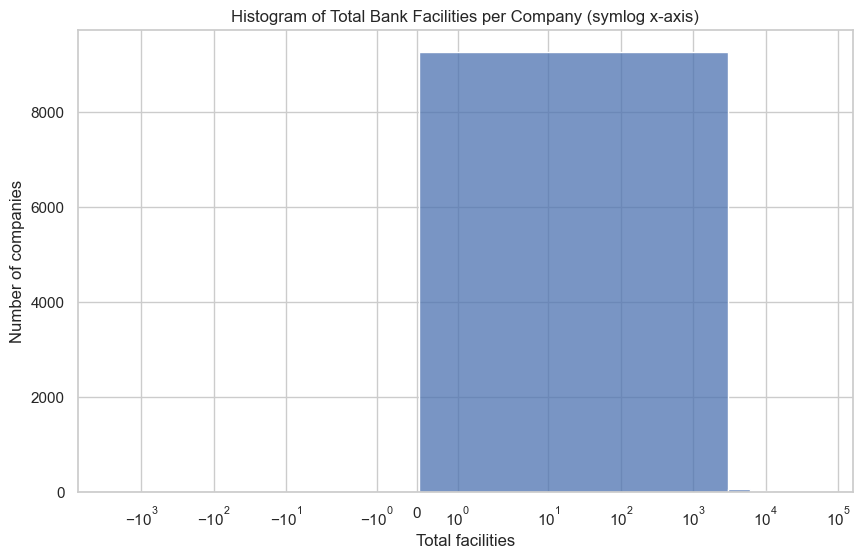

In [6]:
# Histogram of total facilities (log scale often useful)
import matplotlib.ticker as mticker
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(totals[totals>0], bins=50, kde=False, ax=ax)
ax.set_xscale('symlog')
ax.set_title('Histogram of Total Bank Facilities per Company (symlog x-axis)')
ax.set_xlabel('Total facilities')
ax.set_ylabel('Number of companies')
plt.show()

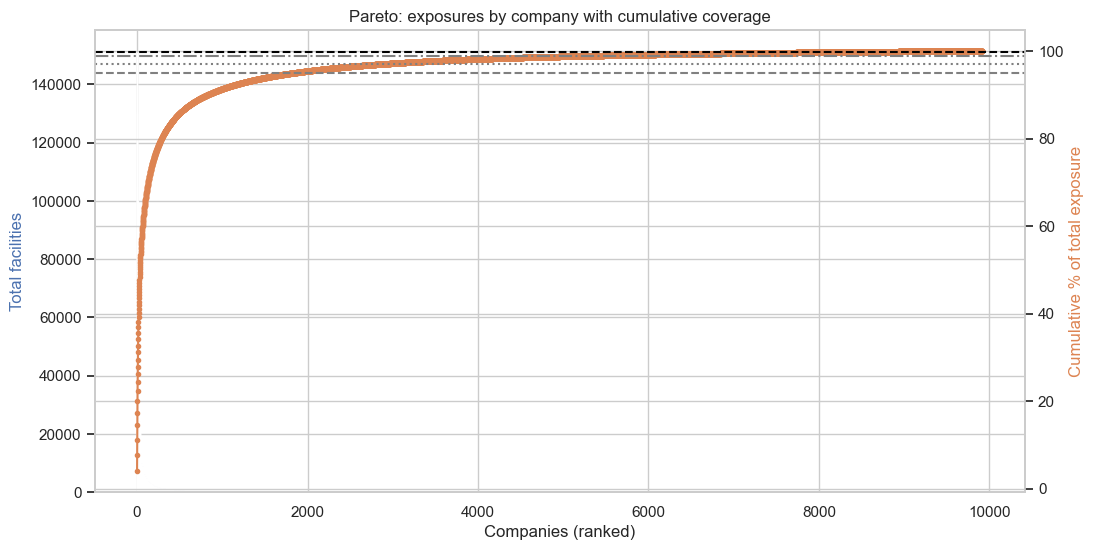

In [7]:
# Pareto chart (cumulative coverage)
df['cumulative'] = df['total_facilities'].cumsum()
total_sum = df['total_facilities'].sum()
df['cum_pct'] = df['cumulative'] / total_sum * 100

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(range(len(df)), df['total_facilities'], color='C0')
ax1.set_xlabel('Companies (ranked)')
ax1.set_ylabel('Total facilities', color='C0')
ax2 = ax1.twinx()
ax2.plot(range(len(df)), df['cum_pct'], color='C1', marker='o', ms=3)
ax2.set_ylabel('Cumulative % of total exposure', color='C1')
ax2.axhline(95, color='gray', linestyle='--')
ax2.axhline(97, color='gray', linestyle=':')
ax2.axhline(99, color='gray', linestyle='-.')
ax2.axhline(99.9, color='black', linestyle='--')
ax1.set_title('Pareto: exposures by company with cumulative coverage')
plt.show()

In [8]:
# Find minimal set of companies covering given percentiles and save CSVs
def companies_covering(pct):
    target = pct/100.0 * total_sum
    cum = df['total_facilities'].cumsum()
    idx = cum.searchsorted(target)
    subset = df.iloc[:idx+1][['companyCode','companyName','total_facilities','cum_pct']]
    return subset

for pct in [95,97,99,99.9]:
    subset = companies_covering(pct)
    print(f'Percent {pct}% => {len(subset)} companies, cumulative sum = {subset.total_facilities.sum():.2f}')

# Save full ranked list and the coverage subsets
out_dir = 'outputs'
os.makedirs(out_dir, exist_ok=True)
df.to_csv(os.path.join(out_dir, 'company_total_facilities_ranked.csv'), index=False)
for pct in [95,97,99,99.9]:
    subset = companies_covering(pct)
    subset.to_csv(os.path.join(out_dir, f'top_companies_covering_{pct}pct.csv'), index=False)
print('Saved CSVs to outputs/')

Percent 95% => 1822 companies, cumulative sum = 3596027.75
Percent 97% => 2818 companies, cumulative sum = 3671688.61
Percent 99% => 5399 companies, cumulative sum = 3747368.15
Percent 99.9% => 8670 companies, cumulative sum = 3781435.31
Saved CSVs to outputs/
